# LinkedIn Job Trend Analysis

This notebook provides an interactive analysis of job market trends, skill demands, and geographic distribution of job opportunities.

## Table of Contents
1. Setup & Data Loading
2. Data Overview & Exploration
3. Skill Demand Analysis
4. Geographic Analysis
5. Role-Based Analysis
6. Visualizations & Heatmaps
7. Insights & Recommendations

## 1. Setup & Data Loading

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from collections import Counter
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [10]:
# Add scripts directory to path for imports
import sys
sys.path.append('../scripts')

# Import our custom modules
from scraper import JobScraper
from cleaner import JobDataCleaner
from analyzer import JobAnalyzer

print("✅ Custom modules imported successfully!")

✅ Custom modules imported successfully!


In [7]:
# Generate sample data (if not already generated)
# This creates 500 realistic job postings for analysis

scraper = JobScraper(output_dir='../data/raw')
df_raw = scraper.run(use_sample_data=True, num_sample_jobs=500)

print(f"\n📊 Generated {len(df_raw)} job postings")
print(f"\nSample of raw data:")
df_raw.head()

2026-01-14 19:39:00,163 - INFO - Using sample data generation mode
2026-01-14 19:39:00,164 - INFO - Generating 500 sample job records
Generating sample data: 100%|██████████| 500/500 [00:00<00:00, 77568.87it/s]
2026-01-14 19:39:00,173 - INFO - Generated 500 sample job records
2026-01-14 19:39:00,179 - INFO - Data saved to ..\data\raw\jobs_raw_20260114_193900.csv and ..\data\raw\jobs_raw_20260114_193900.json



📊 Generated 500 job postings

Sample of raw data:


,job_id,title,company,city,state,location,skills,post_date,source,scraped_date
0,sample_1,Senior Data Analyst,Cloud Ventures #55,Denver,CO,"Denver, CO","[tableau, python, excel, power bi]",2026-01-02,Sample Data,2026-01-14T19:39:00.166145
1,sample_2,Senior Data Analyst,Tech Pioneers #49,Denver,CO,"Denver, CO","[tableau, power bi, pandas, excel, python]",2026-01-07,Sample Data,2026-01-14T19:39:00.166161
2,sample_3,Project Manager,Cloud Ventures #32,Austin,TX,"Austin, TX","[python, sql, excel, communication]",2026-01-14,Sample Data,2026-01-14T19:39:00.166174
3,sample_4,Senior Data Analyst,Tech Pioneers #10,Seattle,WA,"Seattle, WA","[excel, sql, power bi, html, scala]",2026-01-07,Sample Data,2026-01-14T19:39:00.166209
4,sample_5,Python Developer,Tech Pioneers #93,Chicago,IL,"Chicago, IL","[python, sql, communication, excel, terraform,...",2026-01-08,Sample Data,2026-01-14T19:39:00.166226


In [13]:
# Clean the data - reload module to get latest changes
import importlib
import cleaner as cleaner_module
importlib.reload(cleaner_module)
from cleaner import JobDataCleaner

cleaner = JobDataCleaner(
    input_dir='../data/raw',
    output_dir='../data/processed'
)

df = cleaner.run()

print(f"\n✅ Data cleaned successfully!")
print(f"Total records after cleaning: {len(df)}")

2026-01-14 19:41:27,784 - INFO - Loading data from: ..\data\raw\jobs_raw_20260114_193900.csv
2026-01-14 19:41:27,787 - INFO - Loaded 500 records
2026-01-14 19:41:27,788 - INFO - Starting data cleaning process...
2026-01-14 19:41:27,788 - INFO - Standardizing job titles...
2026-01-14 19:41:27,794 - INFO - Parsing and normalizing skills...
2026-01-14 19:41:27,796 - INFO - Standardizing locations...
2026-01-14 19:41:27,798 - INFO - Handling missing values...
2026-01-14 19:41:27,800 - INFO - Removing duplicates...
2026-01-14 19:41:27,805 - INFO - Removed 0 duplicate records
2026-01-14 19:41:27,806 - INFO - Creating role categories...
2026-01-14 19:41:27,809 - INFO - Cleaning complete. Final dataset has 500 records.
2026-01-14 19:41:27,926 - INFO - Cleaned data saved to:
2026-01-14 19:41:27,926 - INFO -   - ..\data\processed\jobs_cleaned_20260114_194127.csv
2026-01-14 19:41:27,927 - INFO -   - ..\data\processed\jobs_cleaned_20260114_194127.json
2026-01-14 19:41:27,927 - INFO -   - ..\data\p


✅ Data cleaned successfully!
Total records after cleaning: 500


## 2. Data Overview & Exploration

In [14]:
# Basic data info
print("📊 DATASET OVERVIEW")
print("="*50)
print(f"Total job postings: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)

📊 DATASET OVERVIEW
Total job postings: 500
Columns: ['job_id', 'title', 'company', 'city', 'state', 'location', 'skills', 'post_date', 'source', 'scraped_date', 'title_standardized', 'skills_normalized', 'city_standardized', 'state_standardized', 'role_category', 'skill_count']

Data types:
job_id                object
title                 object
company               object
city                  object
state                 object
location              object
skills                object
post_date             object
source                object
scraped_date          object
title_standardized    object
skills_normalized     object
city_standardized     object
state_standardized    object
role_category         object
skill_count            int64
dtype: object


In [15]:
# Summary statistics
print("📈 SUMMARY STATISTICS")
print("="*50)
print(f"Unique job titles: {df['title_standardized'].nunique()}")
print(f"Unique companies: {df['company'].nunique()}")
print(f"Unique cities: {df['city_standardized'].nunique()}")
print(f"Average skills per job: {df['skill_count'].mean():.2f}")
print(f"\nRole Categories: {df['role_category'].nunique()}")

📈 SUMMARY STATISTICS
Unique job titles: 18
Unique companies: 435
Unique cities: 10
Average skills per job: 5.46

Role Categories: 8


In [17]:
# Display sample of cleaned data
print("\n📋 Sample of cleaned data:")
df[['title_standardized', 'company', 'city_standardized', 'role_category', 'skill_count']].head(10)


📋 Sample of cleaned data:


,title_standardized,company,city_standardized,role_category,skill_count
0,Data Analyst,Cloud Ventures #55,Denver,Analytics,4
1,Data Analyst,Tech Pioneers #49,Denver,Analytics,5
2,Project Manager,Cloud Ventures #32,Austin,Management,4
3,Data Analyst,Tech Pioneers #10,Seattle,Analytics,5
4,Python Developer,Tech Pioneers #93,Chicago,Software Engineering,6
5,Python Developer,Cloud Systems LLC #73,Boston,Software Engineering,6
6,Data Scientist,Tech Pioneers #30,Chicago,Data Science & ML,8
7,Data Scientist,Global Tech #67,Seattle,Data Science & ML,6
8,Project Manager,Tech Pioneers #16,Boston,Management,4
9,Python Developer,Cloud Systems LLC #72,New York,Software Engineering,6


## 3. Skill Demand Analysis

In [18]:
# Extract and count all skills
all_skills = []
for skills in df['skills_normalized']:
    if isinstance(skills, list):
        all_skills.extend(skills)

skill_counts = Counter(all_skills)
skill_df = pd.DataFrame(skill_counts.most_common(30), columns=['skill', 'count'])
skill_df['percentage'] = (skill_df['count'] / len(df) * 100).round(2)

print("🔥 TOP 15 MOST IN-DEMAND SKILLS")
print("="*50)
for i, row in skill_df.head(15).iterrows():
    bar = '█' * int(row['percentage'] / 2)
    print(f"{row['skill']:20s} | {bar:25s} {row['percentage']:5.1f}%")

🔥 TOP 15 MOST IN-DEMAND SKILLS
python               | ████████████████████████████████████████  81.4%
sql                  | ██████████████████████████████████████  76.8%
excel                | ███████████████████████████  55.4%
communication        | ██████████████████████     44.6%
git                  | █████████                  19.2%
javascript           | ████████                   16.4%
pandas               | ███████                    14.0%
java                 | ██████                     13.6%
aws                  | ██████                     13.0%
rest api             | █████                      10.8%
react                | █████                      10.0%
machine learning     | ████                        9.4%
tableau              | ████                        9.0%
power bi             | ████                        8.8%
docker               | ████                        8.8%


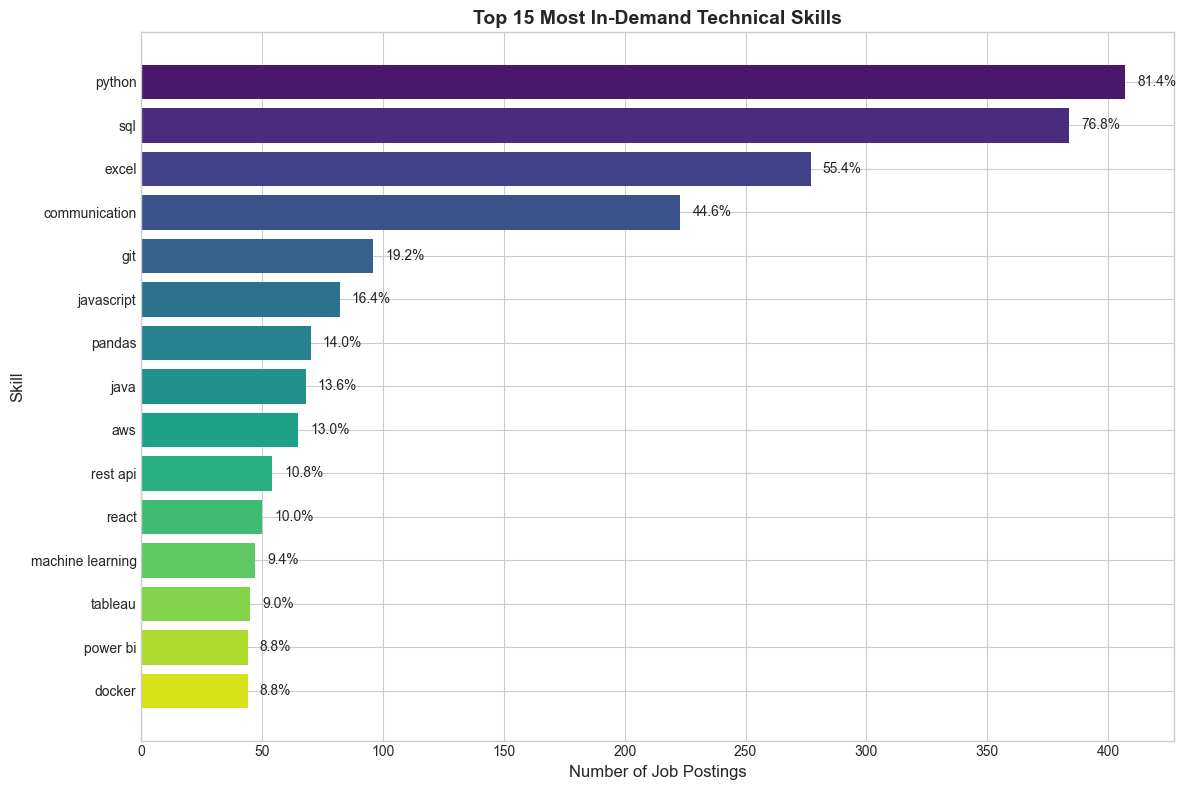

In [19]:
# Create top skills bar chart
fig, ax = plt.subplots(figsize=(12, 8))

top_skills = skill_df.head(15)
colors = sns.color_palette("viridis", len(top_skills))
bars = ax.barh(top_skills['skill'], top_skills['count'], color=colors)

for bar, pct in zip(bars, top_skills['percentage']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
           f'{pct:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_ylabel('Skill', fontsize=12)
ax.set_title('Top 15 Most In-Demand Technical Skills', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../visualizations/top_skills_bar.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Interactive skill chart
fig = px.bar(
    skill_df.head(20),
    x='count',
    y='skill',
    orientation='h',
    color='percentage',
    color_continuous_scale='Viridis',
    title='Top 20 Most In-Demand Skills (Interactive)',
    labels={'count': 'Number of Jobs', 'skill': 'Skill', 'percentage': '% of Jobs'}
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=600
)

fig.write_html('../visualizations/interactive_skills.html')
fig.show()

## 4. Geographic Analysis

In [21]:
# Jobs by city
city_counts = df['city_standardized'].value_counts().reset_index()
city_counts.columns = ['city', 'job_count']
city_counts['percentage'] = (city_counts['job_count'] / len(df) * 100).round(2)

print("🏙️ JOB DISTRIBUTION BY CITY")
print("="*50)
for i, row in city_counts.head(10).iterrows():
    print(f"{row['city']:20s} | {row['job_count']:4d} jobs ({row['percentage']:5.1f}%)")

🏙️ JOB DISTRIBUTION BY CITY
Los Angeles          |   63 jobs ( 12.6%)
Remote               |   58 jobs ( 11.6%)
Denver               |   57 jobs ( 11.4%)
New York             |   54 jobs ( 10.8%)
Chicago              |   51 jobs ( 10.2%)
San Francisco        |   50 jobs ( 10.0%)
Seattle              |   46 jobs (  9.2%)
Austin               |   42 jobs (  8.4%)
Atlanta              |   41 jobs (  8.2%)
Boston               |   38 jobs (  7.6%)


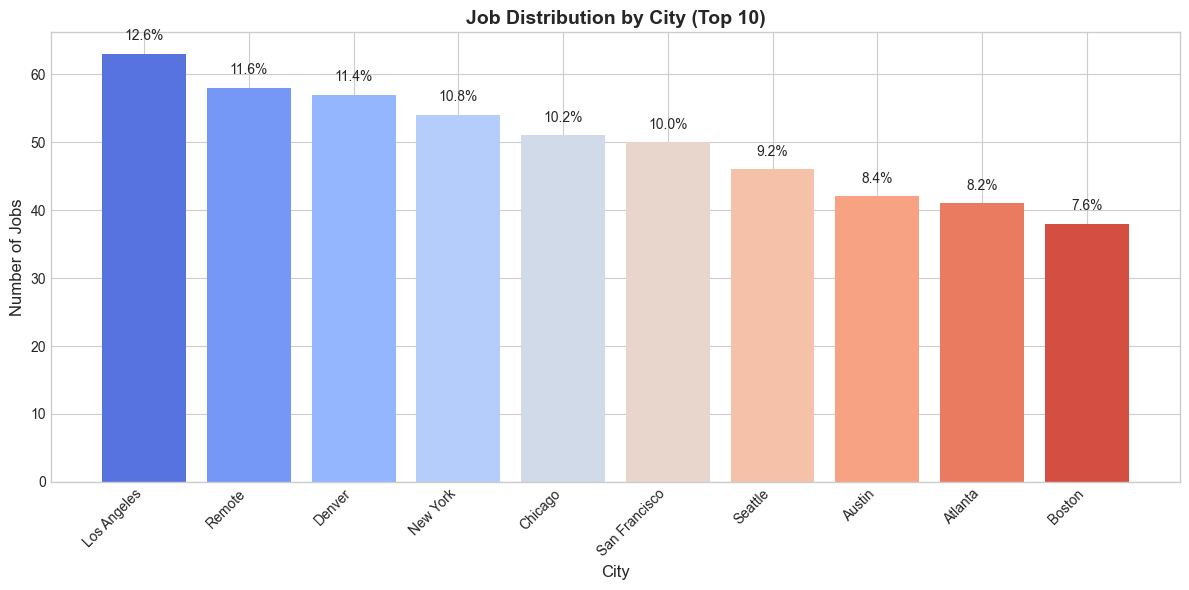

In [22]:
# Jobs by city bar chart
fig, ax = plt.subplots(figsize=(12, 6))

top_cities = city_counts.head(10)
colors = sns.color_palette("coolwarm", len(top_cities))
bars = ax.bar(top_cities['city'], top_cities['job_count'], color=colors)

for bar, pct in zip(bars, top_cities['percentage']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
           f'{pct:.1f}%', ha='center', fontsize=10)

ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Number of Jobs', fontsize=12)
ax.set_title('Job Distribution by City (Top 10)', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visualizations/jobs_by_city.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Skills demand by city
top_cities_list = city_counts.head(8)['city'].tolist()
top_skills_list = skill_df.head(12)['skill'].tolist()

skill_city_data = []

for city in top_cities_list:
    city_jobs = df[df['city_standardized'] == city]
    city_skills = []
    for skills in city_jobs['skills_normalized']:
        if isinstance(skills, list):
            city_skills.extend(skills)
    
    city_skill_counts = Counter(city_skills)
    
    for skill in top_skills_list:
        skill_city_data.append({
            'city': city,
            'skill': skill,
            'count': city_skill_counts.get(skill, 0),
            'percentage': city_skill_counts.get(skill, 0) / len(city_jobs) * 100 if len(city_jobs) > 0 else 0
        })

skill_city_df = pd.DataFrame(skill_city_data)
print(f"✅ Created skill-city matrix with {len(skill_city_df)} data points")

✅ Created skill-city matrix with 96 data points


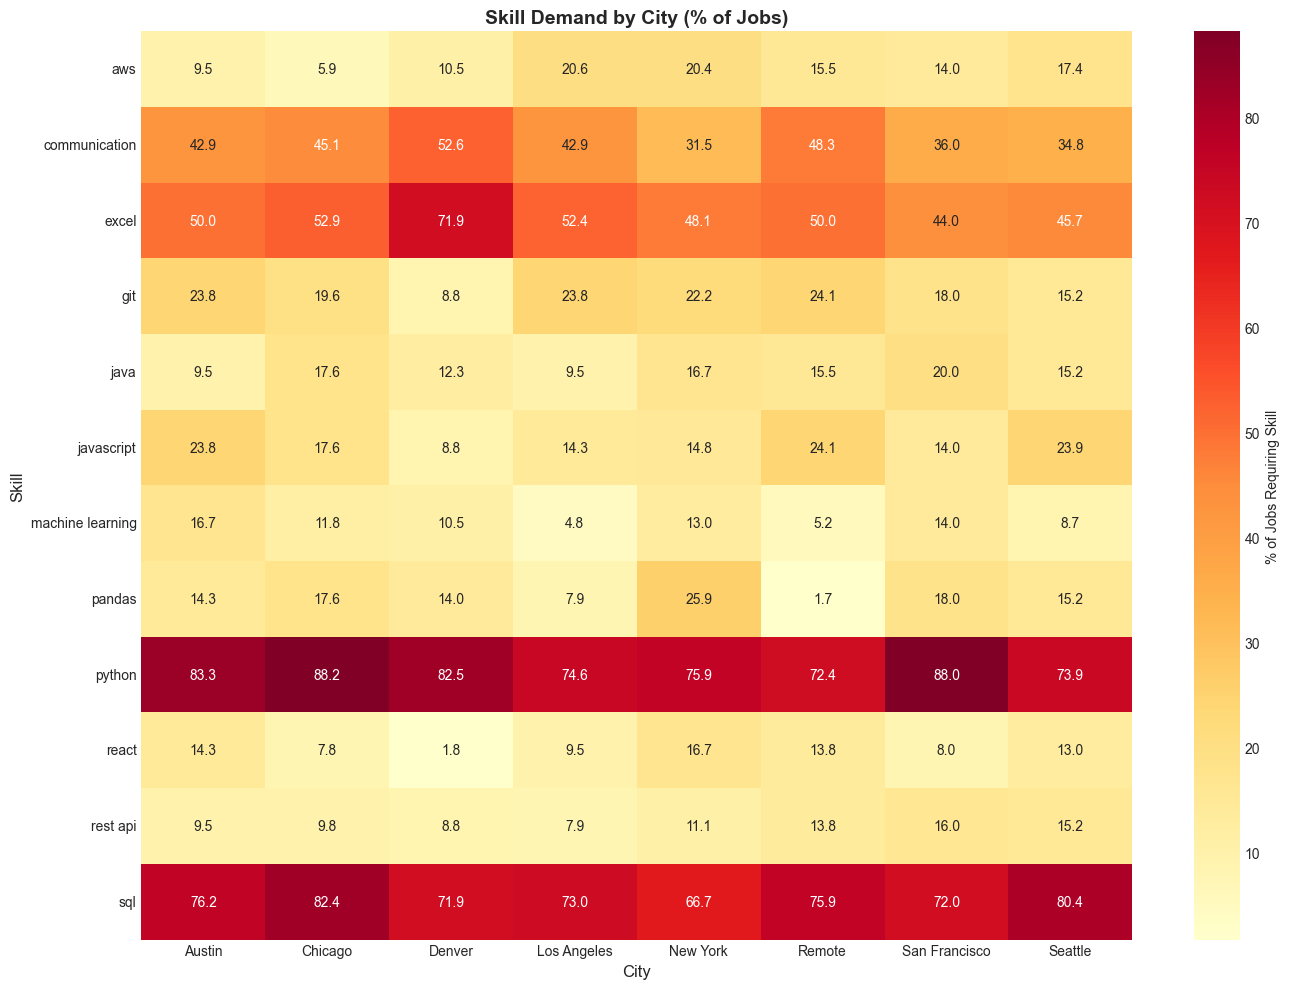

In [24]:
# Skills by city heatmap
heatmap_data = skill_city_df.pivot(
    index='skill',
    columns='city',
    values='percentage'
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': '% of Jobs Requiring Skill'}
)

ax.set_title('Skill Demand by City (% of Jobs)', fontsize=14, fontweight='bold')
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Skill', fontsize=12)

plt.tight_layout()
plt.savefig('../visualizations/skills_city_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Role-Based Analysis

In [25]:
# Role category distribution
role_counts = df['role_category'].value_counts()

print("👔 JOB DISTRIBUTION BY ROLE CATEGORY")
print("="*50)
for role, count in role_counts.items():
    pct = count / len(df) * 100
    print(f"{role:25s} | {count:4d} jobs ({pct:5.1f}%)")

👔 JOB DISTRIBUTION BY ROLE CATEGORY
Software Engineering      |  165 jobs ( 33.0%)
Analytics                 |   85 jobs ( 17.0%)
Data Science & ML         |   74 jobs ( 14.8%)
DevOps & Cloud            |   52 jobs ( 10.4%)
Management                |   35 jobs (  7.0%)
Security & QA             |   33 jobs (  6.6%)
Architecture              |   30 jobs (  6.0%)
Data Engineering          |   26 jobs (  5.2%)


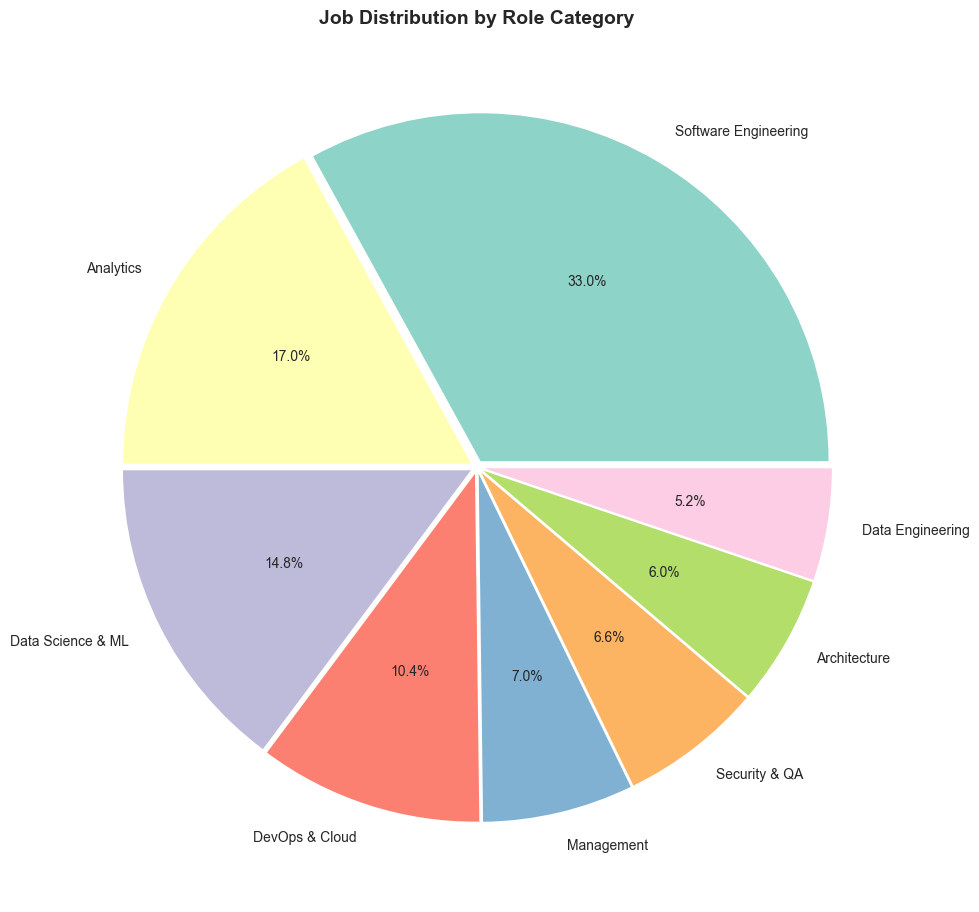

In [26]:
# Role distribution pie chart
fig, ax = plt.subplots(figsize=(10, 10))

colors = sns.color_palette("Set3", len(role_counts))
wedges, texts, autotexts = ax.pie(
    role_counts.values,
    labels=role_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.02] * len(role_counts)
)

ax.set_title('Job Distribution by Role Category', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/role_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# Skills by role analysis
roles = df['role_category'].unique()
skill_role_data = []

for role in roles:
    role_jobs = df[df['role_category'] == role]
    role_skills = []
    for skills in role_jobs['skills_normalized']:
        if isinstance(skills, list):
            role_skills.extend(skills)
    
    role_skill_counts = Counter(role_skills)
    
    for skill in top_skills_list:
        skill_role_data.append({
            'role': role,
            'skill': skill,
            'count': role_skill_counts.get(skill, 0),
            'percentage': role_skill_counts.get(skill, 0) / len(role_jobs) * 100 if len(role_jobs) > 0 else 0
        })

skill_role_df = pd.DataFrame(skill_role_data)
print(f"✅ Created skill-role matrix with {len(skill_role_df)} data points")

✅ Created skill-role matrix with 96 data points


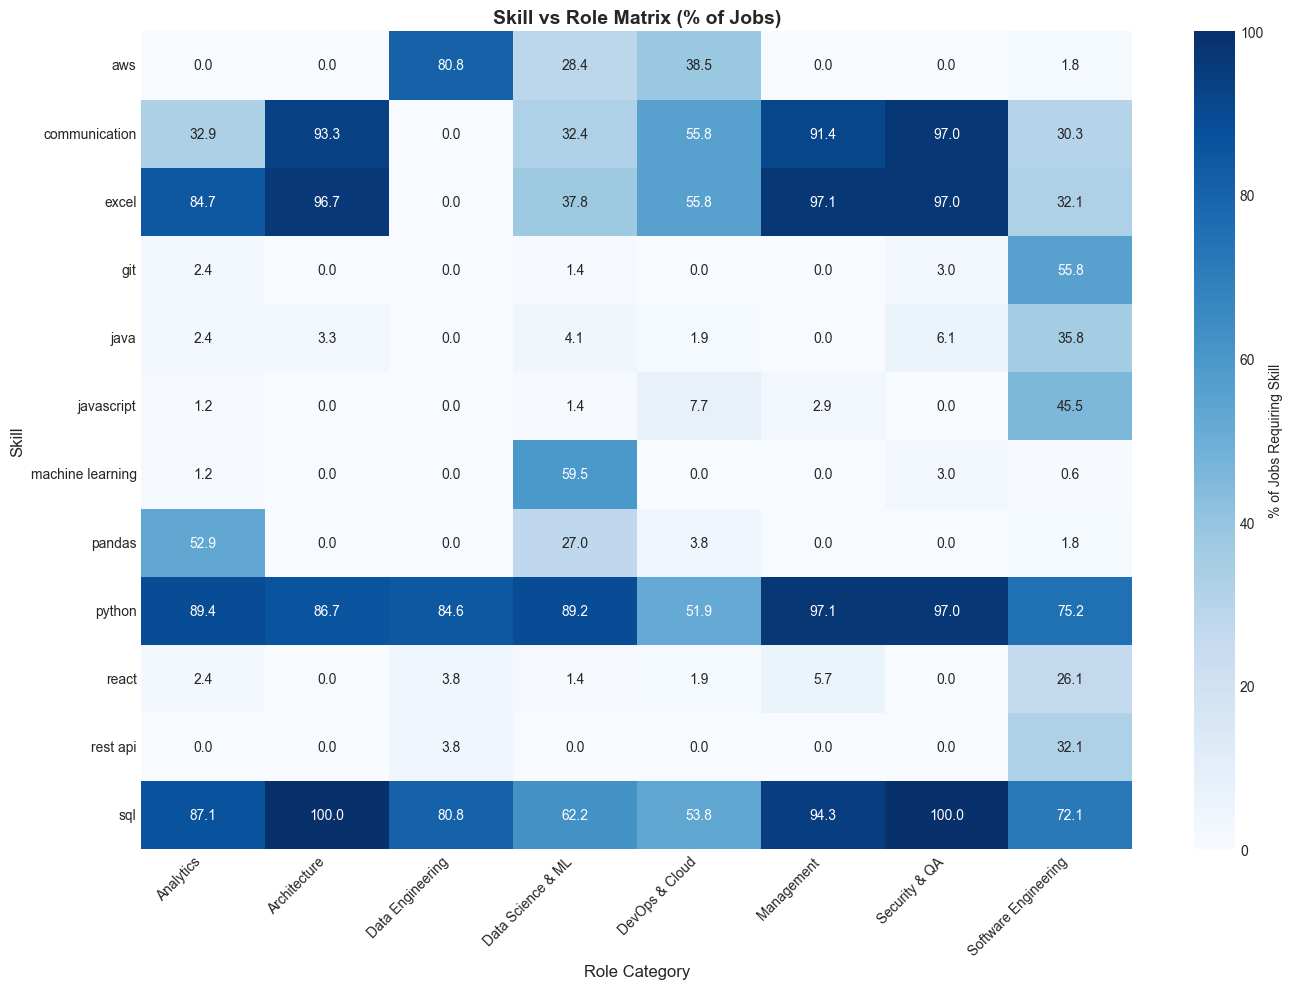

In [28]:
# Skills by role heatmap
role_heatmap_data = skill_role_df.pivot(
    index='skill',
    columns='role',
    values='percentage'
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    role_heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    ax=ax,
    cbar_kws={'label': '% of Jobs Requiring Skill'}
)

ax.set_title('Skill vs Role Matrix (% of Jobs)', fontsize=14, fontweight='bold')
ax.set_xlabel('Role Category', fontsize=12)
ax.set_ylabel('Skill', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visualizations/skills_role_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Additional Visualizations

In [29]:
# Interactive heatmap with Plotly
fig = px.imshow(
    heatmap_data,
    color_continuous_scale='YlOrRd',
    title='Skill Demand by City (%) - Interactive',
    labels={'color': '% of Jobs'}
)

fig.update_layout(height=700)
fig.write_html('../visualizations/interactive_heatmap.html')
fig.show()

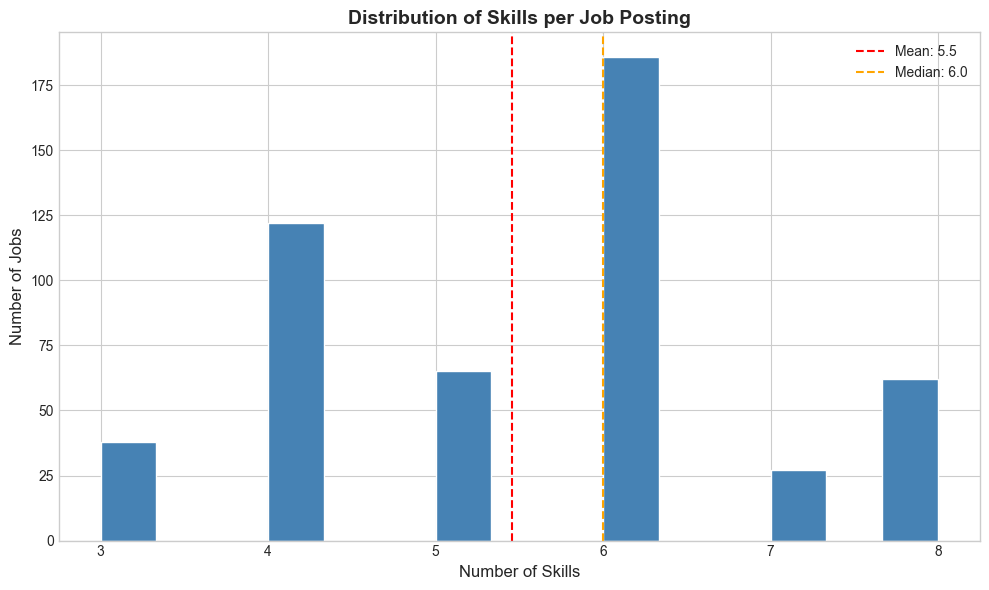

In [30]:
# Skill count distribution
fig, ax = plt.subplots(figsize=(10, 6))

df['skill_count'].hist(bins=15, ax=ax, color='steelblue', edgecolor='white')

ax.axvline(df['skill_count'].mean(), color='red', linestyle='--', 
           label=f'Mean: {df["skill_count"].mean():.1f}')
ax.axvline(df['skill_count'].median(), color='orange', linestyle='--',
           label=f'Median: {df["skill_count"].median():.1f}')

ax.set_xlabel('Number of Skills', fontsize=12)
ax.set_ylabel('Number of Jobs', fontsize=12)
ax.set_title('Distribution of Skills per Job Posting', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../visualizations/skill_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Insights & Recommendations

In [31]:
# Generate comprehensive insights
print("="*60)
print("📊 JOB MARKET INSIGHTS & RECOMMENDATIONS")
print("="*60)

print("\n🔥 TOP 5 MUST-HAVE SKILLS:")
print("-"*40)
for i, row in skill_df.head(5).iterrows():
    print(f"  {i+1}. {row['skill'].upper()} - Required in {row['percentage']:.1f}% of jobs")

print("\n🏙️ BEST CITIES FOR TECH JOBS:")
print("-"*40)
for i, row in city_counts.head(5).iterrows():
    print(f"  {i+1}. {row['city']} - {row['job_count']} opportunities")

print("\n👔 HOTTEST ROLE CATEGORIES:")
print("-"*40)
for i, (role, count) in enumerate(role_counts.head(5).items(), 1):
    pct = count / len(df) * 100
    print(f"  {i}. {role} - {pct:.1f}% of all jobs")

📊 JOB MARKET INSIGHTS & RECOMMENDATIONS

🔥 TOP 5 MUST-HAVE SKILLS:
----------------------------------------
  1. PYTHON - Required in 81.4% of jobs
  2. SQL - Required in 76.8% of jobs
  3. EXCEL - Required in 55.4% of jobs
  4. COMMUNICATION - Required in 44.6% of jobs
  5. GIT - Required in 19.2% of jobs

🏙️ BEST CITIES FOR TECH JOBS:
----------------------------------------
  1. Los Angeles - 63 opportunities
  2. Remote - 58 opportunities
  3. Denver - 57 opportunities
  4. New York - 54 opportunities
  5. Chicago - 51 opportunities

👔 HOTTEST ROLE CATEGORIES:
----------------------------------------
  1. Software Engineering - 33.0% of all jobs
  2. Analytics - 17.0% of all jobs
  3. Data Science & ML - 14.8% of all jobs
  4. DevOps & Cloud - 10.4% of all jobs
  5. Management - 7.0% of all jobs


In [32]:
# City-specific skill recommendations
print("\n💡 CITY-SPECIFIC SKILL RECOMMENDATIONS:")
print("="*60)

for city in city_counts.head(5)['city']:
    city_data = skill_city_df[skill_city_df['city'] == city].nlargest(5, 'percentage')
    print(f"\n📍 {city}:")
    print(f"   Top skills: {', '.join(city_data['skill'].tolist())}")


💡 CITY-SPECIFIC SKILL RECOMMENDATIONS:

📍 Los Angeles:
   Top skills: python, sql, excel, communication, git

📍 Remote:
   Top skills: sql, python, excel, communication, git

📍 Denver:
   Top skills: python, sql, excel, communication, pandas

📍 New York:
   Top skills: python, sql, excel, communication, pandas

📍 Chicago:
   Top skills: python, sql, excel, communication, git


In [33]:
# Role-specific skill recommendations
print("\n💼 ROLE-SPECIFIC SKILL RECOMMENDATIONS:")
print("="*60)

for role in role_counts.index:
    role_data = skill_role_df[skill_role_df['role'] == role].nlargest(5, 'percentage')
    print(f"\n🎯 {role}:")
    print(f"   Essential skills: {', '.join(role_data['skill'].tolist())}")


💼 ROLE-SPECIFIC SKILL RECOMMENDATIONS:

🎯 Software Engineering:
   Essential skills: python, sql, git, javascript, java

🎯 Analytics:
   Essential skills: python, sql, excel, pandas, communication

🎯 Data Science & ML:
   Essential skills: python, sql, machine learning, excel, communication

🎯 DevOps & Cloud:
   Essential skills: excel, communication, sql, python, aws

🎯 Management:
   Essential skills: python, excel, sql, communication, react

🎯 Security & QA:
   Essential skills: sql, python, excel, communication, java

🎯 Architecture:
   Essential skills: sql, excel, communication, python, java

🎯 Data Engineering:
   Essential skills: python, sql, aws, rest api, react


In [34]:
# Export final summary to Excel
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_file = f'../visualizations/job_analysis_report_{timestamp}.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Overview sheet
    overview = pd.DataFrame({
        'Metric': ['Total Jobs', 'Unique Skills', 'Unique Cities', 'Unique Companies', 'Avg Skills/Job'],
        'Value': [len(df), len(skill_df), df['city_standardized'].nunique(), 
                  df['company'].nunique(), df['skill_count'].mean().round(2)]
    })
    overview.to_excel(writer, sheet_name='Overview', index=False)
    
    # Top skills
    skill_df.to_excel(writer, sheet_name='Top Skills', index=False)
    
    # Jobs by city
    city_counts.to_excel(writer, sheet_name='Jobs by City', index=False)
    
    # Skills by city
    heatmap_data.to_excel(writer, sheet_name='Skills by City')
    
    # Skills by role
    role_heatmap_data.to_excel(writer, sheet_name='Skills by Role')

print(f"\n✅ Analysis report exported to: {output_file}")
print("\n📁 All visualizations saved to: ../visualizations/")


✅ Analysis report exported to: ../visualizations/job_analysis_report_20260114_194651.xlsx

📁 All visualizations saved to: ../visualizations/


---

## Summary

This analysis provides:
1. **Top Skills Chart** - Identifying the most in-demand technical skills
2. **Skills by City Heatmap** - Geographic distribution of skill requirements
3. **Skills by Role Matrix** - Role-specific skill requirements
4. **Job Demand Recommendations** - Actionable insights for job seekers

### Key Deliverables:
- 📊 Trend analysis visualizations (PNG files)
- 🗺️ Interactive heatmaps (HTML files)
- 📈 Skill vs Role matrix
- 📋 Excel report with all analysis data
- 💡 Job demand recommendations